## Walmart project
## Part1: EDA + Cleaning
## Part2: Baseline Model

In [1]:
# librairies
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.figure_factory as ff

# Jedha color palette
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6",
                     "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"  # mettre "iframe" sur JULIE

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Selection
from sklearn.model_selection import cross_val_score, GridSearchCV

# Metrics
from sklearn.metrics import r2_score, mean_squared_error

In [13]:
dataset = pd.read_csv("Walmart_Store_sales.csv")
dataset.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


## part1: EDA + Cleaning

In [3]:
dataset.shape
#(150, 8)

(150, 8)

In [14]:
dataset.describe(include="all")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


part 1: cleaning

In [15]:
#missing data
print("Missing values per column:")
dataset.isnull().sum()

# la variable cible "Weekly_Sales" a 14 missing data à droper ou remplacer par la moyenne

Missing values per column:


Store            0
Date            18
Weekly_Sales    14
Holiday_Flag    12
Temperature     18
Fuel_Price      14
CPI             12
Unemployment    15
dtype: int64

In [16]:
# Suppression immédiate des lignes sans cible ou sans date
dataset = dataset.dropna(subset=["Weekly_Sales", "Date"])


In [17]:
# Extraction chronologique propre
dataset["Date"] = pd.to_datetime(dataset["Date"], format="%d-%m-%Y")
dataset["Year"] = dataset["Date"].dt.year
dataset["Month"] = dataset["Date"].dt.month
dataset["Day"] = dataset["Date"].dt.day
dataset["DayOfWeek"] = dataset["Date"].dt.dayofweek
dataset = dataset.drop(columns=["Date"])


In [18]:
# Nettoyage rigoureux des Outliers à 3 sigmas sur TOUTES les features économiques
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
print(f"📐 Dimensions initiales du dataset : {dataset.shape}")

for col in num_cols:
    dataset = dataset.dropna(subset=[col])
    mean = dataset[col].mean()
    std = dataset[col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    dataset = dataset[(dataset[col] >= lower_bound) & (dataset[col] <= upper_bound)]

print(f"📊 Dimensions après nettoyage global des Outliers : {dataset.shape}\n")

📐 Dimensions initiales du dataset : (118, 11)
📊 Dimensions après nettoyage global des Outliers : (80, 11)



part 1: EDA

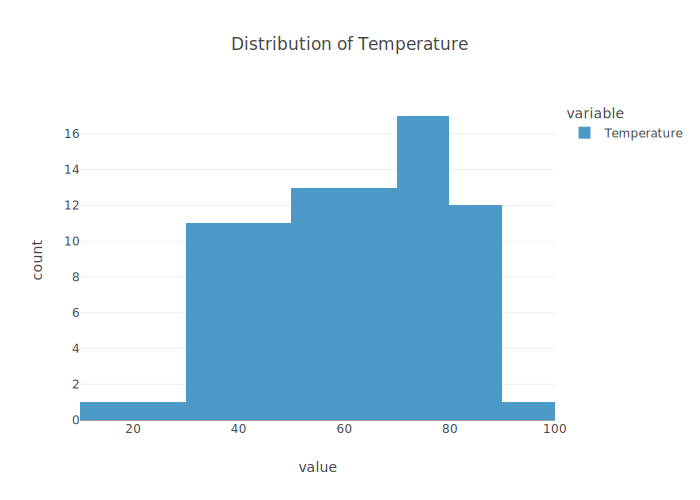

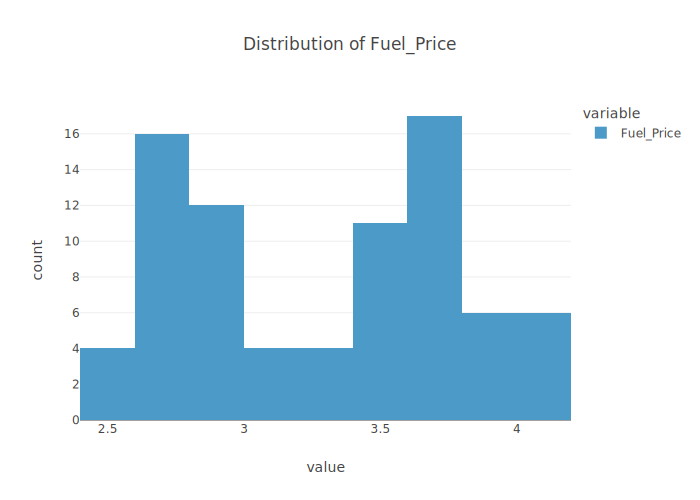

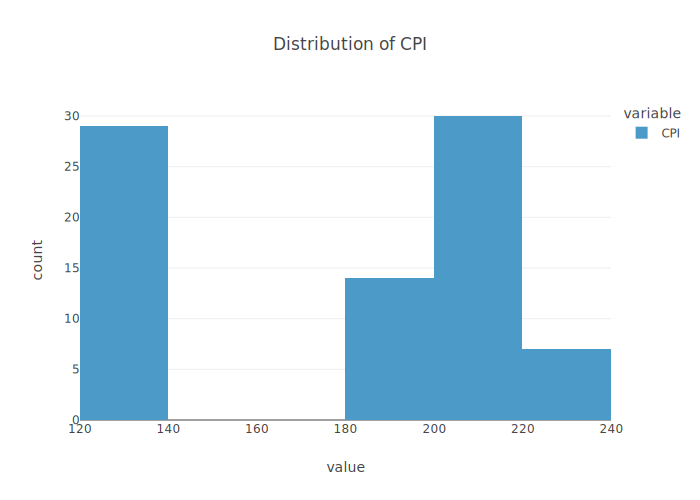

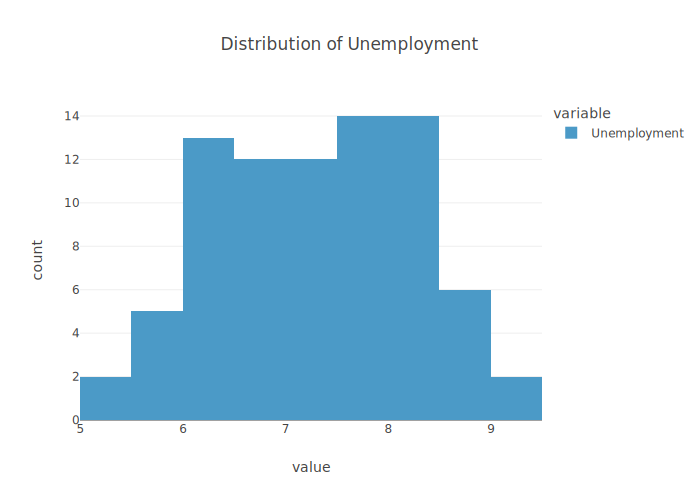

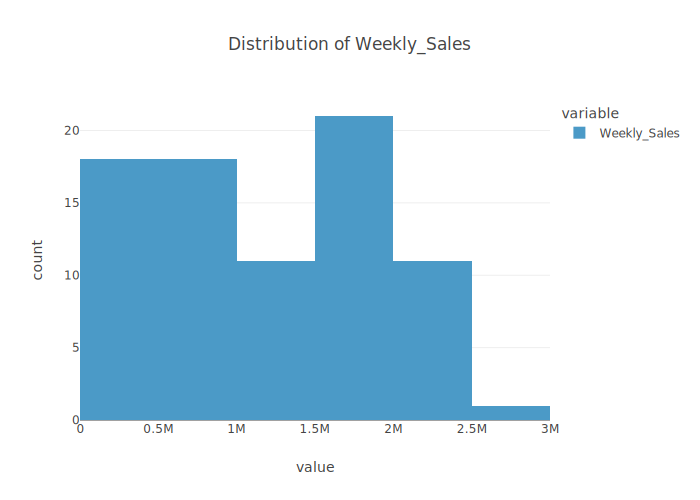

In [19]:
# description des variables quantitatives
num_features = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Weekly_Sales"]

for col in num_features:
    fig = px.histogram(dataset[col], title=f"Distribution of {col}")
    fig.show()


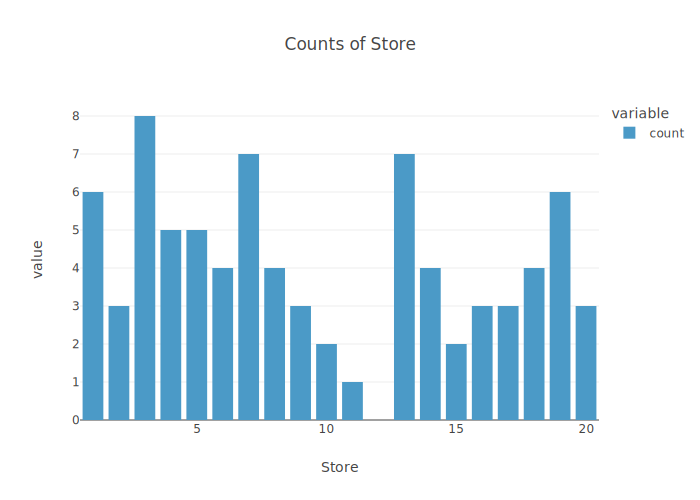

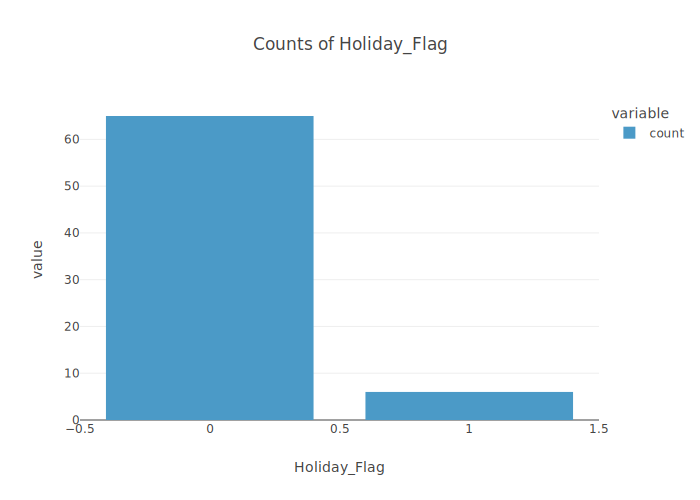

In [20]:
# description des variables explicatives qualitatives
cat_features = ["Store", "Holiday_Flag"]

for col in cat_features:
    fig = px.bar(dataset[col].value_counts(), title=f"Counts of {col}")
    fig.show()


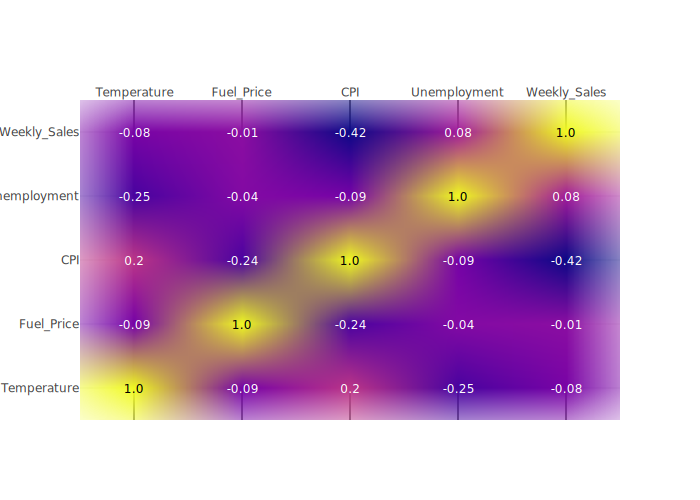

In [21]:
# matrice de correlation
corr_matrix = dataset[num_features].corr().round(2)

fig = ff.create_annotated_heatmap(
    corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist()
)
fig.show()


# PART 2: baseline model

part 2: pre processing

In [22]:
y = dataset["Weekly_Sales"]
X = dataset.drop(columns=["Weekly_Sales"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configuration des pipelines de transformation
cat_features = ["Store", "Holiday_Flag"]
num_features = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Day", "DayOfWeek"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)


part 2: model

In [23]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

# Évaluation de la Baseline
print("📈 --- PERFORMANCES DU MODÈLE BASELINE ---")
print(f"Train R² : {r2_score(y_train, model.predict(X_train)):.4f}")
print(f"Test R²  : {r2_score(y_test, model.predict(X_test)):.4f}\n")


📈 --- PERFORMANCES DU MODÈLE BASELINE ---
Train R² : 0.9821
Test R²  : 0.9637



In [24]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("R2 score :", r2)


MSE : 16931906842.672764
R2 score : 0.963732235760879


Le modèle explique 96,3 % de la variance des ventes hebdomadaires


In [25]:
# Train predictions
y_train_pred = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("Train MSE:", mse_train)
print("Train R2:", r2_train)


Train MSE: 8127365557.479858
Train R2: 0.9820943694655776


In [26]:
## Calcul des coefficients

lin_reg = model.named_steps["regressor"]
encoded_cat = model.named_steps["preprocessing"] \
                    .named_transformers_["cat"] \
                    .named_steps["encoder"] \
                    .get_feature_names_out(cat_features)


all_features = num_features + list(encoded_cat)

coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": lin_reg.coef_
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(by="abs_coefficient", ascending=False).drop(columns=["abs_coefficient"])

print("📋 Top 10 de l'importance réelle des coefficients (Axe Métier) :")
display(coef_df.head(10))
print("\n")

📋 Top 10 de l'importance réelle des coefficients (Axe Métier) :


,feature,coefficient
11,Store_4.0,1.613607e+06
12,Store_5.0,-1.549624e+06
17,Store_10.0,1.536985e+06
19,Store_13.0,1.448450e+06
10,Store_3.0,-1.445106e+06
16,Store_9.0,-1.398589e+06
15,Store_8.0,-9.740662e+05
22,Store_16.0,-9.549483e+05
14,Store_7.0,-8.661291e+05
25,Store_19.0,8.448611e+05


## PART 3: Fight overfitting

part 3: ridge regression

In [27]:
ridge_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", Ridge())
])

param_grid_ridge = {
    "regressor__alpha": [0.1, 1, 10, 50, 100, 200, 500]
}

grid_ridge = GridSearchCV(
    ridge_model,
    param_grid_ridge,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

In [28]:
print("Best alpha (Ridge):", grid_ridge.best_params_)
print("Best R2 (train CV):", grid_ridge.best_score_)

y_pred_ridge = grid_ridge.predict(X_test)
print("Test: ")
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))


Best alpha (Ridge): {'regressor__alpha': 0.1}
Best R2 (train CV): 0.7789806825611698
Test: 
Ridge MSE: 20773249718.252495
Ridge R2: 0.9555041655814448


part 3: Lasso 

In [29]:
lasso_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", Lasso(max_iter=10000))
])

param_grid_lasso = {"regressor__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
grid_lasso = GridSearchCV(lasso_model, param_grid_lasso, cv=5, scoring="r2", n_jobs=-1)
grid_lasso.fit(X_train, y_train)

print("🎯 --- RÉSULTATS DU MODÈLE RÉGULARISÉ (LASSO) ---")
print(f"Meilleur paramètre Hyperparamètre Alpha : {grid_lasso.best_params_}")
print(f"Lasso Train R² : {r2_score(y_train, grid_lasso.predict(X_train)):.4f}")
print(f"Lasso Test R²  : {r2_score(y_test, grid_lasso.predict(X_test)):.4f}")

🎯 --- RÉSULTATS DU MODÈLE RÉGULARISÉ (LASSO) ---
Meilleur paramètre Hyperparamètre Alpha : {'regressor__alpha': 1}
Lasso Train R² : 0.9821
Lasso Test R²  : 0.9635


c:\Users\marzo\anaconda3\envs\jedha_base\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.948e+10, tolerance: 2.905e+09



In [30]:
print("Best alpha (Lasso):", grid_lasso.best_params_)
print("Best R2 (train CV):", grid_lasso.best_score_)

y_pred_lasso = grid_lasso.predict(X_test)

print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))


Best alpha (Lasso): {'regressor__alpha': 1}
Best R2 (train CV): 0.8917747179803284
Lasso MSE: 17034641723.621094
Lasso R2: 0.9635121799528716


 L'optimisation par validation croisée retient un paramètre $\alpha = 1$ avec un $R^2$ d'entraînement moyen de $0.8917$, garantissant une sélection de variables robuste et un modèle simplifié. > L'évaluation finale confirme l'absence totale de surapprentissage, puisque le modèle Lasso maintient un score $R^2$ exceptionnel de $0.9635$ sur l'ensemble de test, expliquant ainsi plus de $96,3\%$ de la variance des ventes hebdomadaires.